In [4]:
%matplotlib widget

In [18]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(1, 'src')

from Plot import grid


In [6]:
def FDEM1D(sgm, thk, height=0):
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    #height = 0
    strength = np.pi

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    OUT = []

    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0, strength = strength)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() 
        ip = (H_Hs/H_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0, strength = strength)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() 
        ip = (V_Hs/V_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() 
        ip = (P_Hs/P_Hp).real.amp() 

        OUT.append([op, ip])

    return np.array(OUT).ravel()  

In [7]:
def FDEM3D(model_sig, model_air, height = 0):
    """ Simulate Dualem842S in 3D """
    startTime = time.time()
    
    frequency = 9000 # Hertz
    offsets_H = np.array([2, 4, 8])
    offsets_V = offsets_H.copy()
    offsets_P = np.array([2.1, 4.1, 8.1])
    
    # Define sources geometry
    # source = [x, y, z, azimuth, dip]
    Hsource_coords = [0, 0, height, 0, 90]
    Vsource_coords = [0, 0, height, 90, 0]
   # Psource_coords = Hsource_coords
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsource_coords)
    Vsource = emg3d.TxMagneticPoint(Vsource_coords)
   # Psource = emg3d.TxMagneticPoint(Psource_coords)
    
    # Solve Electrical fields
    print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = model_sig, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = model_sig, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = model_air, source = Vsource, frequency = frequency)
    
    # Get magnetic fields
    print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = model_sig, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = model_air, efield = Efield_V_p)
    
    # Get fields at receivers
    print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_H, offsets_H*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_H, offsets_H*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_V, offsets_V*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_V, offsets_V*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    
    # Calculate output components OP and IP
    print('getting output components')
    #OUT = []
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    #OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    #OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    #OUT.append([op_p, ip_p])
    
    # src x pos | rec x pos | midpoint | data
    OUT = {'src_x' : [Hsource_coords[0], Hsource_coords[0], Hsource_coords[0],
                      Vsource_coords[0], Vsource_coords[0], Vsource_coords[0],
                      Hsource_coords[0], Hsource_coords[0], Hsource_coords[0]],
           'rec_x' : np.hstack((offsets_H, offsets_V, offsets_P)),
           'midpx' : np.hstack(((offsets_H - Hsource_coords[0])/2,
                                (offsets_V - Vsource_coords[0])/2,
                                (offsets_P - Hsource_coords[0])/2)),
           'op' : np.hstack((op_h, op_v, op_p)),
           'ip' : np.hstack((ip_h, ip_v, op_p)) 
          }
               
    endTime = time.time()
    print('Done in', (endTime - startTime), 'seconds!')
    return OUT
    

In [8]:
# Define model
sig = np.array([100/1000])
thk = np.array([])

sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

In [9]:
# Define source

height = 0.1
azi = 0
dip = 90
off = np.array([2,4,8])
frequency = 9000
src_coords = [0, 0, height, azi, dip]

# Define mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = sig_3d,
                         center = [0.2,0.2,0],
                         mapping='Conductivity',
                         domain = ([-1, 30],[-6, 6],[-13,1]),
                         min_width_limits = [0.4, 0.4, 0.2],
                         center_on_edge=True)

# Define receivers
rec_coords = [off, np.zeros_like(off), height, azi, dip]

In [10]:
mesh

TensorMesh: 1,048,576 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    128       -110.19        139.39      0.40     15.18    1.16
   y     64       -112.10        143.64      0.40     31.54    1.29
   z    128       -127.20        134.81      0.20     19.81    1.17

In [11]:
# Populate grid

sig_x = np.ones(mesh.n_cells)*sig_3d[0]
sig_air = np.ones(mesh.n_cells)*sig_3d[0]
sig_x[mesh.cell_centers[:,2] <= depth_3d[0]] = sig_3d[1]
#sig_x[mesh.cell_centers[:,2] <= depth_3d[1]] = sig_3d[2]
#sig_x[mesh.cell_centers[:,2] <= depth_3d[2]] = sig_3d[3]

#x = (mesh.cell_centers[:,0] > 0) & (mesh.cell_centers[:,0] < 1)
#y = mesh.cell_centers[:,1] > 0
#z = (mesh.cell_centers[:,2] < -2) & (mesh.cell_centers[:,2] > -4)

#sig_x[x*y*z] = 200/1000

In [12]:
Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')

In [13]:
#Model.interpolate_to_grid(new_grid)

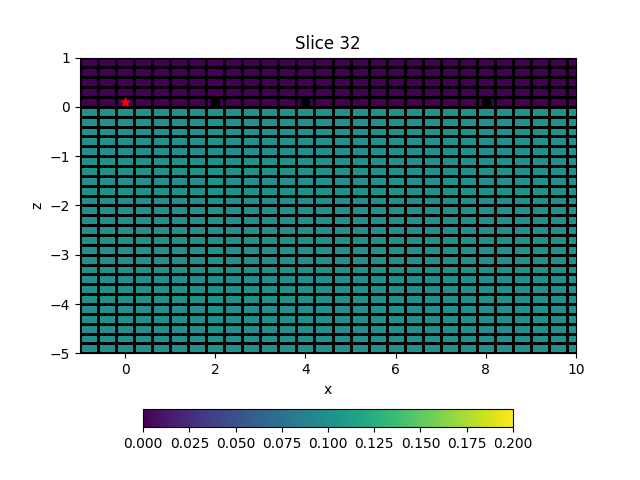

In [14]:
fig, ax = plt.subplots()

f0 = mesh.plot_slice(Model.property_x,
               normal = 'Y',
               v_type='CC',
               clim=[0,0.2],
               ax=ax,
               grid=True)
ax.set_xlim([-1,10])
ax.set_ylim([-5,1])
ax.scatter(src_coords[0], src_coords[2], c='r', marker = '*')
ax.scatter(rec_coords[0], rec_coords[1]+height, c='k')

fig.colorbar(f0[0], ax=ax, orientation='horizontal', fraction=0.05)

# Calculate data

In [15]:
data_3D = FDEM3D(model_sig = Model,
                 model_air = Model_air, 
                 height=height)

Solving sources...
getting magnetic fields...
magnetic field at receivers...
getting output components
Done in 387.1538054943085 seconds!


In [16]:
data_3D

{'src_x': [0, 0, 0, 0, 0, 0, 0, 0, 0],
 'rec_x': array([2. , 4. , 8. , 2. , 4. , 8. , 2.1, 4.1, 8.1]),
 'midpx': array([1.  , 2.  , 4.  , 1.  , 2.  , 4.  , 1.05, 2.05, 4.05]),
 'op': array([0.0058174 , 0.02104742, 0.05910396, 0.00577304, 0.02321613,
        0.08267853, 0.00354743, 0.02776506, 0.10406342]),
 'ip': array([0.00073201, 0.00549298, 0.03479739, 0.00039258, 0.00299381,
        0.0207006 , 0.00354743, 0.02776506, 0.10406342])}

In [49]:
df = pd.DataFrame(data_3D)
df

,src_x,rec_x,midpx,op,ip
0,0,2.0,1.00,0.005817,0.000732
1,0,4.0,2.00,0.021047,0.005493
2,0,8.0,4.00,0.059104,0.034797
3,0,2.0,1.00,0.005773,0.000393
4,0,4.0,2.00,0.023216,0.002994
5,0,8.0,4.00,0.082679,0.020701
6,0,2.1,1.05,0.003547,0.003547
7,0,4.1,2.05,0.027765,0.027765
8,0,8.1,4.05,0.104063,0.104063


In [51]:
df1 = pd.DataFrame({'src_x' : [],
                    'rec_x' : [],
                    'midpx' : [],
                    'op' : [],
                    'ip' : []})
pd.concat([df,df1])
df

,src_x,rec_x,midpx,op,ip
0,0,2.0,1.00,0.005817,0.000732
1,0,4.0,2.00,0.021047,0.005493
2,0,8.0,4.00,0.059104,0.034797
3,0,2.0,1.00,0.005773,0.000393
4,0,4.0,2.00,0.023216,0.002994
5,0,8.0,4.00,0.082679,0.020701
6,0,2.1,1.05,0.003547,0.003547
7,0,4.1,2.05,0.027765,0.027765
8,0,8.1,4.05,0.104063,0.104063


In [153]:
data_1D = FDEM1D(sig, thk, height=height)

Text(0.5, 0, 'Data point')

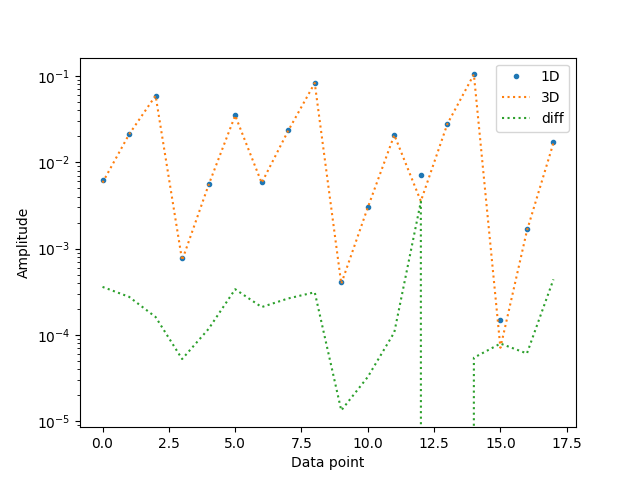

In [154]:
plt.figure()
plt.semilogy(data_1D, '.', label = '1D')
plt.semilogy(data_3D, ':', label = '3D')
plt.semilogy(data_1D - data_3D, ':', label = 'diff')
plt.legend()
plt.ylabel('Amplitude')
plt.xlabel('Data point')

# Let's recreate the model for LCI

In [29]:
models_LCI = np.load('modelLCI.npy')

In [30]:
npos = np.shape(models_LCI)[0]
nlay = 3

In [31]:
depths = np.zeros((npos, nlay))
depths[:,1] = - models_LCI[:,0]
depths[:,2] = - models_LCI[:,0] - models_LCI[:,1]

In [32]:
# size of ny for each meter to be divided by 0.125
# ny = 80

In [33]:
models_LCI_grid = grid(models_LCI, depthmax = 10, ny=80)

Text(0.5, 1.0, 'LCI model')

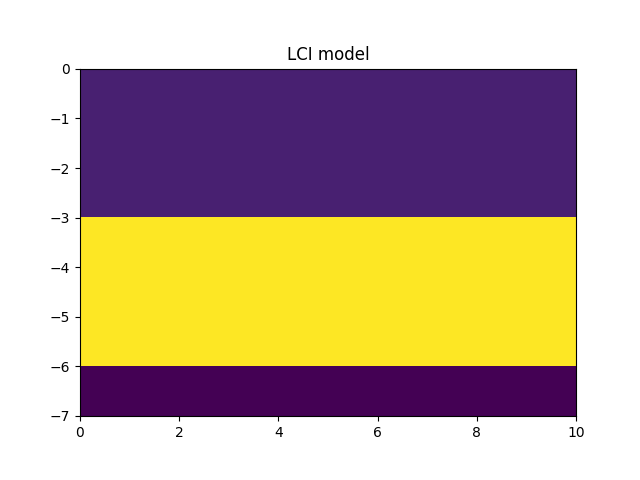

In [34]:
plt.figure()
plt.imshow(models_LCI_grid.T, extent=[0,10, -10,0])
plt.ylim([-7,0])
plt.title('LCI model')

In [35]:
np.shape(models_LCI_grid)

(10, 80)

In [36]:
# Populate a mesh

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0]
sig_air = np.ones(mesh.n_cells)*sig_3d[0]

# Fill before position 0

x = mesh.cell_centers[:,0] <=0
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[0,0]) & (mesh.cell_centers[:,2] > depths[0,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[0,1]) & (mesh.cell_centers[:,2] > depths[0,2])
z_lay3 = (mesh.cell_centers[:,2] < depths[0,2])

sig_x[x*y*z_lay1] = models_LCI[0,2]
sig_x[x*y*z_lay2] = models_LCI[0,3]
sig_x[x*y*z_lay3] = models_LCI[0,4]


for p in range(npos):
   # print('position:',p)
    x = (mesh.cell_centers[:,0] > p) & (mesh.cell_centers[:,0] < p+1)
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[p,0]) & (mesh.cell_centers[:,2] > depths[p,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[p,1]) & (mesh.cell_centers[:,2] > depths[p,2])
    z_lay3 = (mesh.cell_centers[:,2] < depths[p,2])

    sig_x[x*y*z_lay1] = models_LCI[p,2]
    sig_x[x*y*z_lay2] = models_LCI[p,3]
    sig_x[x*y*z_lay3] = models_LCI[p,4]

# fill after position 8

x = (mesh.cell_centers[:,0] > npos) 
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[-1,0]) & (mesh.cell_centers[:,2] > depths[-1,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[-1,1]) & (mesh.cell_centers[:,2] > depths[-1,2])
z_lay3 = (mesh.cell_centers[:,2] < depths[-1,2])

sig_x[x*y*z_lay1] = models_LCI[-1,2]
sig_x[x*y*z_lay2] = models_LCI[-1,3]
sig_x[x*y*z_lay3] = models_LCI[-1,4]

In [37]:
Model_LCI = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

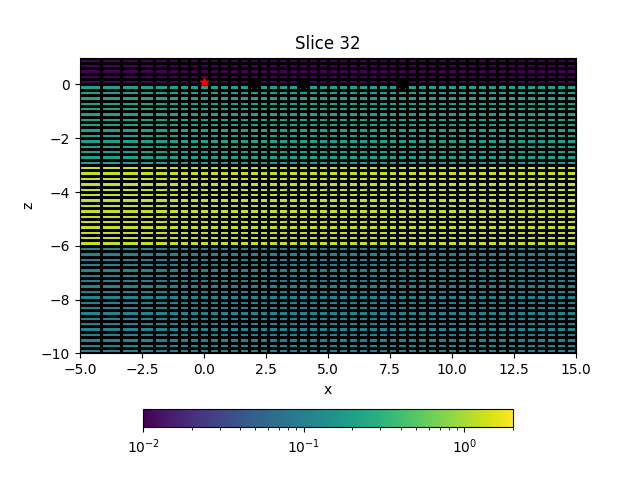

In [38]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots()

f0 = mesh.plot_slice(Model_LCI.property_x,
               normal = 'Y',
               v_type='CC',
               #clim=[0,1],
               pcolor_opts={'norm': LogNorm(vmin=0.01, vmax=2)},
               ax=ax,
               grid=True)
ax.set_xlim([-5,15])
ax.set_ylim([-10,1])
ax.scatter(src_coords[0], src_coords[2], c='r', marker = '*')
ax.scatter(rec_coords[0], rec_coords[1], c='k')

fig.colorbar(f0[0], ax=ax, orientation='horizontal', fraction=0.05)

In [67]:
xsrc = np.linspace(0, 9, npos, endpoint=True)

OUT = pd.DataFrame({})

startTime = time.time()
for p in range(2):
    print('Position:', p)
    print('Defining geometry')
    # Define source coordinates
    src_x = xsrc[p]
    Hsrc_coords = [src_x, 0, height, 0, 90]
    Vsrc_coords = [src_x, 0, height, 90, 0]
    print('source:', Hsrc_coords)
    
    # Define H and V receivers coordinates
    offsets_HV = np.array([xsrc[p]+2, xsrc[p]+4, xsrc[p]+8])
    print('offsets:',offsets_HV)
    #rec_coords = [offsets_HV, offsets_HV*0, np.ones_like(offsets_HV)*height, azi, dip]
    
    # Define P receivers coordinates
    offsets_P = np.array([xsrc[p]+2.1, xsrc[p]+4.1, xsrc[p]+8.1])
    #rec_coords_p = [offsets_P, offsets_P*0, np.ones_like(offsets_P)*height, azi, dip]
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsrc_coords)
    Vsource = emg3d.TxMagneticPoint(Vsrc_coords)
    
    # Solve Electrical fields
    print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = Model_LCI, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = Model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = Model_LCI, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = Model_air, source = Vsource, frequency = frequency)

    # Get magnetic fields
    print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = Model_LCI, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = Model_LCI, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_V_p)
    
    # Get fields at receivers
    print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_HV, offsets_HV*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    #print('H_Hrec_p : ', H_Hrec_p)
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_HV, offsets_HV*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    #print('H_Vrec_p : ', H_Vrec_p)
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 90))*(2j * np.pi * frequency * mu_0)
    #print('H_Prec_p : ', H_Prec_p)
    
     # Calculate output components OP and IP
    print('getting output components')
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    #OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    #OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    #OUT.append([op_p, ip_p])
    
    OUT_i = pd.DataFrame({'src_x' : [Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0],
                                     Vsrc_coords[0], Vsrc_coords[0], Vsrc_coords[0],
                                     Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0]],
                          'rec_x' : np.hstack((offsets_HV, offsets_HV, offsets_P)),
                          'midpx' : np.hstack((Hsrc_coords[0] + (offsets_HV - Hsrc_coords[0])/2,
                                               Vsrc_coords[0] + (offsets_HV - Vsrc_coords[0])/2,
                                               Hsrc_coords[0] + (offsets_P - Hsrc_coords[0])/2)),
                          'op' : np.hstack((op_h, op_v, op_p)),
                          'ip' : np.hstack((ip_h, ip_v, ip_p)) 
                          })
    
    OUT = pd.concat([OUT, OUT_i], ignore_index=True)
    print()
endTime = time.time()
print('Done in', (endTime - startTime), 'seconds!')
    

Position: 0
Defining geometry
source: [0.0, 0, 0.1, 0, 90]
offsets: [2. 4. 8.]
Solving sources...
getting magnetic fields...
magnetic field at receivers...
getting output components
Position: 1
Defining geometry
source: [1.0, 0, 0.1, 0, 90]
offsets: [3. 5. 9.]
Solving sources...
getting magnetic fields...
magnetic field at receivers...
getting output components
Done in 729.5901782512665 seconds!


In [68]:
OUT

,src_x,rec_x,midpx,op,ip
0,0.0,2.0,1.00,0.015533,0.006132
1,0.0,4.0,2.00,0.060695,0.042846
2,0.0,8.0,4.00,0.096926,0.194890
3,0.0,2.0,1.00,0.013759,0.003273
4,0.0,4.0,2.00,0.060464,0.024337
5,0.0,8.0,4.00,0.210022,0.146687
6,0.0,2.1,1.05,0.008159,0.000870
7,0.0,4.1,2.05,0.077150,0.020614
8,0.0,8.1,4.05,0.314233,0.187162
9,1.0,3.0,2.00,0.503776,0.196480


In [24]:
data_3D = np.array(OUT)
data_3D = data_3D.reshape(npos,2,3,3)

In [25]:
data_1D = np.load('dataLCI.npy')
data_1D = data_1D.reshape(npos,2,3,3)

In [26]:
def Plot_Datas(data_1, data_2, label_1='1D', label_2='3D', ax=None):
    
    if ax == None:
        fig, ax = plt.subplots(3,2, sharex=True)

    ax[0,0].semilogy(data_1[:,0,0,0], '*b', label = '2m true')
    ax[0,0].semilogy(data_1[:,0,0,1], '*r', label = '4m true')
    ax[0,0].semilogy(data_1[:,0,0,2], '*g', label = '8m true')
    ax[0,0].semilogy(data_2[:,0,0,0], ':b', label = '2m est')
    ax[0,0].semilogy(data_2[:,0,0,1], ':r', label = '4m est')
    ax[0,0].semilogy(data_2[:,0,0,2], ':g', label = '8m est')
    ax[0,0].set_title('OP component H coils')

    ax[0,1].semilogy(data_1[:,1,0,0], '*b', label = '2m ' + label_1)
    ax[0,1].semilogy(data_1[:,1,0,1], '*r', label = '4m ' + label_1)
    ax[0,1].semilogy(data_1[:,1,0,2], '*g', label = '8m ' + label_1)
    ax[0,1].semilogy(data_2[:,1,0,0], ':b', label = '2m ' + label_2)
    ax[0,1].semilogy(data_2[:,1,0,1], ':r', label = '4m ' + label_2)
    ax[0,1].semilogy(data_2[:,1,0,2], ':g', label = '8m ' + label_2)
    ax[0,1].set_title('IP component H coils')
    ax[0,1].legend(bbox_to_anchor=(1.1, 1.05))

    ax[1,0].semilogy(data_1[:,0,1,0], '*b', label = '2m true')
    ax[1,0].semilogy(data_1[:,0,1,1], '*r', label = '4m true')
    ax[1,0].semilogy(data_1[:,0,1,2], '*g', label = '8m true')
    ax[1,0].semilogy(data_2[:,0,1,0], ':b', label = '2m est')
    ax[1,0].semilogy(data_2[:,0,1,1], ':r', label = '4m est')
    ax[1,0].semilogy(data_2[:,0,1,2], ':g', label = '8m est')
    ax[1,0].set_title('OP component V coils')

    ax[1,1].semilogy(data_1[:,1,1,0], '*b', label = '2m true')
    ax[1,1].semilogy(data_1[:,1,1,1], '*r', label = '4m true')
    ax[1,1].semilogy(data_1[:,1,1,2], '*g', label = '8m true')
    ax[1,1].semilogy(data_2[:,1,1,0], ':b', label = '2m est')
    ax[1,1].semilogy(data_2[:,1,1,1], ':r', label = '4m est')
    ax[1,1].semilogy(data_2[:,1,1,2], ':g', label = '8m est')
    ax[1,1].set_title('IP component V coils')

    ax[2,0].semilogy(data_1[:,0,2,0], '*b', label = '2m true')
    ax[2,0].semilogy(data_1[:,0,2,1], '*r', label = '4m true')
    ax[2,0].semilogy(data_1[:,0,2,2], '*g', label = '8m true')
    ax[2,0].semilogy(data_2[:,0,2,0], ':b', label = '2m est')
    ax[2,0].semilogy(data_2[:,0,2,1], ':r', label = '4m est')
    ax[2,0].semilogy(data_2[:,0,2,2], ':g', label = '8m est')
    ax[2,0].set_title('OP component P coils')

    ax[2,1].semilogy(data_1[:,1,2,0], '*b', label = '2m true')
    ax[2,1].semilogy(data_1[:,1,2,1], '*r', label = '4m true')
    ax[2,1].semilogy(data_1[:,1,2,2], '*g', label = '8m true')
    ax[2,1].semilogy(data_2[:,1,2,0], ':b', label = '2m est')
    ax[2,1].semilogy(data_2[:,1,2,1], ':r', label = '4m est')
    ax[2,1].semilogy(data_2[:,1,2,2], ':g', label = '8m est')
    ax[2,1].set_title('IP component P coils')

    plt.tight_layout()

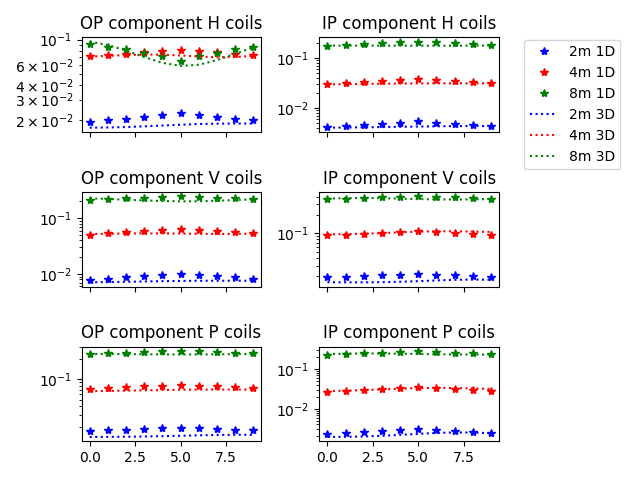

In [27]:
Plot_Datas(data_1D, data_3D)

In [28]:
np.save('dataLCI_3D', data_3D)